# Pipeline stage 1: the search for phage-encoded acetyltransferases

### Stage 1.3: assessing proteins of unknown function for acetyltransferase potential using predicted protein structures

As acetyltransferases tend to be highly divergent on sequence level (as can be seen in the CATH [GNAT superfamily sequence/structure diversity plot](https://www.cathdb.info/version/v4_4_0/superfamily/3.40.630.30)), we expect acetyltransferases to be underannotated in phage genomes. Given that GNATs are structurally highly conserved, we will here use a structure-based pipeline to identify additional phage-encoded acetyltransferases, that might have escaped sequence-based protein annotation efforts.

**Goals:**
* Select a set of proteins representative of the phage proteins of unknown function, void of annotated acetyltransferases.
* Prepare necessary files for predicting protein structures of these proteins on HPC.
* Predict & inspect protein structures of these proteins.
* Prepare necessary files for analysing protein structures of these proteins on HPC.
* Identify proteins with likely acetyltransferase function based on predicted protein structure & similar protein structures.
* Assess likelihood acetyltransferase function based on predicted protein structure & similar protein structures.

**Requires:**
*  phage_data.tsv stored in a_input/ : a tab-seperated phage-centric overview of the virus & host taxonomic information from the Virus-Host database, summarizing all included phages (one phage per line).
* input_search.tsv stored in a_input/protein_overview/ : a tab-seperated aggregated overview of the NCBI proteins that are unannotated and within the expected size range of acetyltransferases for all phages (one NCBI protein entry per line).
* assessed_annotated_acetyltransferases.tsv stored in b_assess_annotated/ : a tab-seperated overview of the NCBI and UniProt proteins of our phages that (i) contain 'GNAT' or 'acetyltransferase' in their protein name and (ii) have a structure that matches to proteins annotated as 'acetyltransferase' in either the PDB or the AlphaFold database, with each row representing one unique phage-protein pair.
*  structure prediction template files submit_vibfold.py, VIBFold.py, VIBFold_adapted_functions.py and submit.sh stored in ../templates/ : template job inputs and scripts to be modified. The [VIBFold](https://github.com/jasperzuallaert/VIBFold/tree/main) scripts are adapted from those by Zuallaert J., available under an [MIT License](https://github.com/jasperzuallaert/VIBFold/blob/main/LICENSE).
*  structure comparison template files data_foldseek_5.csv and script_foldseek_5.slurm stored in ../templates/ : template job inputs and scripts to be modified.

**Requires (to reproduce):**
* list_obsolete_PDB_ids_15jul2024.txt stored in ../associated_data/: a .txt file containing all the obsolete PDB identifiers at runtime (July '24), with each line representing one obsolete PDB identifier
* dict_pdb_PDBidch_UniProtID_jul2024.csv stored in ../associated_data/ : a comma-seperated file storing the dictionary linking PDB identifier & chain combinations in the FoldSeek output files (against the PDB database) to the linked UniProt identifier, as obtained at runtime (July '24). Each column is one dictionary entry, the first row contains the PDB identifier & chain combination, the second row the linked UniProt identifier(s).
* dict_pdb_UniProtID_NCBIuid_jul2024.csv stored in ../associated_data/ : a comma-seperated file storing the dictionary linking UniProt identifiers obtained based on the PDB identifier & chain combination in the FoldSeek output files (against the PDB database) to the NCBI protein unique identifier of the PROTEIN used as search query for the FoldSeek run, as obtained at runtime (July '24). Each column is one dictionary entry, the first row contains the UniProt identifiers, the second row the NCBI unique identifiers.
* dict_UniProtID_function_jul2024.csv stored in ../associated_data/ : a comma-seperated file storing the dictionary linking UniProt identifiers to the fetched UniProt protein names, as obtained at runtime (July '24, UniProt release 2024_03). Each column is one dictionary entry, the first row contains the UniProt identifiers, the second row contains the linked protein name(s).

**Generates:**
* assessed_unknown.tsv :  a tab-seperated overview of the NCBI proteins of our phages that (i) that are unannotated and within the expected size range of acetyltransferases and (ii) belong to a protein cluster that has a predicted structure that matches to proteins annotated as 'acetyltransferase' and/or 'GNAT' in at least 50% of either the PDB or the AlphaFold database FoldSeek hits, with each row representing one unique phage-protein pair (column names as in assessed_annotated_acetyltransferases.tsv). 
* in folder proteins_cluster:
    * all_unknown.fasta : a multi-FASTA file containing sequence information from (i) all proteins of unknown function extracted from input_search.tsv, and (ii) all assessed, annotated acetyltransferases from the assessed_annotated_acetyltransferases.tsv
    * mmseqs.pbs : the .pbs job script for clustering the proteins of unknown function with the acetyltransferase sequences
    * clustering output files (see MMseqs docs for more information on the different files):
        * all_unknown(.XX) with XX indicating a dbtype, index, lookup or source file
        * all_unknown_h(.XX) with XX indicating a dbtype, index 
        * all_unknown_clustered.XX with X a number between 0 and 95
        * all_unknown_clustered.XX with XX indicting a tsv, index or dbtype file
        * MMseqs.e/o file: error/output files from HPC job
* in folder structure_prediction (final folder structure, after lifting the 'batch' structure implemented to facilitate submission):
    * in folder fastas:
        * ncbi_uid_PROTEIN.fasta : protein fasta file for every protein of unknown function selected for structure prediction, identifiable through its NCBI unique identifier
    * submit_vibfold_ncbi_uid_PROTEIN.py: python script to submit VIBFold job for specific protein, identifiable through its NCBI unique identifier
    * submit_batch_XX.sh, VIBFold.py, VIBFold_adapted_functions.py: python/bash scripts to submit and run VIBFold jobs
    * in folder results:
        * in folder ncbi_uid_PROTEIN:
            * 5 unrelaxed .pdb protein structures (ncbi_uid_PROTEIN_unrelaxed_rank_X_model_X_ptmx_1.pdb) and 1 relaxed .pdb protein structure (ncbi_uid_PROTEIN_relaxed.pdb): AlphaFold predicted structures
            * 3 .png files: 2 for PAE (one for all models - ncbi_uid_PROTEIN_PAE.png, one for the best model - best_PAE.png) and 1 for pLDDT/coverage (ncbi_uid_PROTEIN_coverage_lddt.png): quality metrics AlphaFold predicted structures depicted visually
            * 1 ncbi_uid_PROTEIN_info.log file
            * 1 ncbi_uid_PROTEIN_msa_ids.txt: .txt file containing all sequence identifiers of the sequences used in the MSA. Every line is a new identifier.
            * query.fasta: input sequence used for AlphaFold run
            * 1 ncbi_uid_PROTEIN_rank_1_model_X_ptmx_1.json: json file with PAE scores of the best AlphaFold prediction
    * VIBFold_ncbi_uid_PROTEIN.eXXXXX and VIBFold_ncbi_uid_PROTEIN.oXXXXX: error and output files for VIBFold jobs
* in folder investigate_nans:
    * in folder proteins_cluster: the exact same as for non-nested folder proteins_cluster, only now with all proteins having a proper sequence assigned (so no sequence has a NaN sequence anymore).
* in folder structure_comparison (final folder structure, after lifting the 'batch' structure implemented to facilitate submission):
    * in folder foldseek_in:
        * ncbi_uid_PROTEIN_relaxed.pdb (or ncbi_uid_PROTEIN_best.pdb) : the (relaxed, if available) best AlphaFold prediction, copied from structure_prediction/results/ncbi_uid_PROTEIN
        * data_foldseek_5_batch_XX.csv with XX reflecting batch number for job execution: comma separated data file containing all parameters for the FoldSeek jobscripts. Every 3 columns represent 1 protein being processed by FoldSeek (column 1: input PDB file, column 2: name of output for FoldSeek run against PDB, column 3: name of output for FoldSeek run against AlphaFold database). Each row contains the job parameters for 5 proteins.
        * script_foldseek_5.slurm : jobscript to run FoldSeek on the HPC
    * in folder foldseek_out:
        * ncbi_uid_PROTEIN_aln_pdb.tsv: tab-seperated output of FoldSeek run against the PDB database (v.2024-02-20)
        * ncbi_uid_PROTEIN_aln_af50m.tsv: tab-seperated output of FoldSeek run against the AlphaFold database (v.4)
        * slurm-XXXX.out : output files for FoldSeek jobs
    * in folder output_processed:
        * ncbi_uid_PROTEIN_foldseek_pdb_filtered.tsv: tab-seperated output of FoldSeek run against the PDB database, after filtering on quality metrics (including the self calculated pLDDT of the aligned fraction - column pLDDT_qAln)
        * ncbi_uid_PROTEIN_foldseek_af50m_filtered.tsv: tab-seperated output of FoldSeek run against the AlphaFold database, after filtering on quality metrics (including the self calculated pLDDT of the aligned fraction - column pLDDT_qAln)
        * ncbi_uid_PROTEIN_foldseek_pdb_processed.tsv: tab-seperated output of FoldSeek run against the PDB database, after filtering on quality metrics (including the self calculated pLDDT of the aligned fraction - column pLDDT_qAln) obtained by adding in protein function annotations (column protein_descr) to ncbi_uid_PROTEIN_foldseek_pdb_filtered.tsv if any of the FoldSeek hits for that PROTEIN contained 'acetyltransferase' and/or 'GNAT'
        * ncbi_uid_PROTEIN_foldseek_af50m_processed.tsv: tab-seperated output of FoldSeek run against the AlphaFold database, after filtering on quality metrics (including the self calculated pLDDT of the aligned fraction - column pLDDT_qAln) obtained by adding in protein function annotations (column protein_descr) to ncbi_uid_PROTEIN_foldseek_af50m_filtered.tsv if any of the FoldSeek hits for that PROTEIN contained 'acetyltransferase' and/or 'GNAT'

**Overwrites**:
* PHAGE_input_search.tsv stored in a_input/protein_overview/ for PHAGEs: Epa18_taxid_2719188, Epa22_taxid_2719572, Epa24_taxid_2719573, Henu5_taxid_2499902, HJ01_taxid_3018995,  F_HA0480sp_Pa1651_taxid_2923005  : reason overwite: NaN sequence fetched for a protein of these phages. This overwrite operation replaces the NaN sequence with the correct sequence from NCBI.
* input_search.tsv stored in a_input/protein_overview/ : reason overwite: NaN sequence fetched for 6 proteins. This overwrite operation replaces the NaN sequence with the correct sequence from NCBI

#### General settings, imports, variables and environments

Conda environment: viral_act_assess_unknown

Created with `conda create -n viral_act_assess_unknown python=3.10`. Then installed `jupyter notebook`, `pandas` through conda (command `conda install`) & `more_iterools`, `biopython` and `seaborn` through pip (command below).

In [ ]:
!pip install more-itertools

In [ ]:
!pip install biopython

In [ ]:
!pip install seaborn

In [1]:
!conda list --explicit

# This file may be used to create an environment using:
# $ conda create --name <env> --file <this file>
# platform: win-64
# created-by: conda 24.11.3
@EXPLICIT
https://conda.anaconda.org/conda-forge/noarch/ca-certificates-2025.10.5-h4c7d964_0.conda
https://conda.anaconda.org/conda-forge/noarch/python_abi-3.10-8_cp310.conda
https://conda.anaconda.org/conda-forge/noarch/tzdata-2025b-h78e105d_0.conda
https://conda.anaconda.org/conda-forge/win-64/ucrt-10.0.26100.0-h57928b3_0.conda
https://conda.anaconda.org/conda-forge/win-64/winpty-0.4.3-4.tar.bz2
https://conda.anaconda.org/conda-forge/win-64/libwinpthread-12.0.0.r4.gg4f2fc60ca-h57928b3_10.conda
https://conda.anaconda.org/conda-forge/win-64/vcomp14-14.44.35208-h818238b_32.conda
https://conda.anaconda.org/conda-forge/win-64/vc14_runtime-14.44.35208-h818238b_32.conda
https://conda.anaconda.org/conda-forge/win-64/vc-14.3-h2b53caa_32.conda
https://conda.anaconda.org/conda-forge/win-64/bzip2-1.0.8-h0ad9c76_8.conda
https://conda.anaconda.org/

In [2]:
# imports
import csv
import glob
import json
import matplotlib
import os
import requests
import shutil
import sys

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from more_itertools import batched, collapse

import Bio
from Bio.PDB import *
from json.decoder import JSONDecodeError

In [3]:
# settings for requests
sess = requests.Session()
adapter = requests.adapters.HTTPAdapter(max_retries = 10)
sess.mount("https://", adapter)

In [4]:
# clear reference to different directories
pipeline_search_dir = os.getcwd()
master_dir = os.path.abspath(os.path.join(pipeline_search_dir, os.pardir, os.pardir))

In [ ]:
# creating a directory for all the data we will generate
os.mkdir(os.path.join(pipeline_search_dir, "c_assess_unknown"))

#### Goal 1: select a set of proteins representative of the phage proteins of unknown function, void of annotated acetyltransferases

Previously, in notebook Code_search_input.ipynb, we have generated an overview of all phage proteins of unknown function with a size of 100 to 850 amino acids. This size limit was based on the expectation that phage-encoded acetyltransferases would primarily be GNATs, and based on the results of the assessment of the annotated acetyltransferases, this size limit is deemed suitable. 

We calculated that there were 20,874 unique sequences in this dataset. Before we start predicting protein structures, we will try to diminish the size of this group, to not waste computational resources. To do this, we will first cluster all protein sequences together with the assessed, annotated acetyltransferases using MMseqs2. Then, we will remove all clusters containing any sequence from our acetyltransferase set. Finally, we will only use the remaining cluster representatives as input for structure prediction.

In [5]:
# reading in the phage data
phage_data = pd.read_csv(os.path.join(pipeline_search_dir, "a_input", "phage_data.tsv"), sep = "\t")
# generating a list of our phages
phages = list(phage_data["name_taxid"]) 
# sadly some phage names are computationally challenging, containing / or . 
    # let's make a dict of those with the computationally easier alternative
annoying_phage_names_dict = {}
for phage in phages:
    if "." in phage:
        annoying_phage_names_dict[phage] = phage.replace(".", "_")
    if "/" in phage:
        annoying_phage_names_dict[phage] = phage.replace("/", "_")

In [71]:
# reading in the proteins of unknown function
unannotated_proteins = pd.read_csv(os.path.join(pipeline_search_dir, "a_input", "protein_overview", "input_search.tsv") , sep = "\t")

For the clustering with MMseqs, we have to create one multi-fasta file containing all sequences.

In [ ]:
os.mkdir(os.path.join(pipeline_search_dir, "c_assess_unknown", "proteins_cluster"))

*Note on reproducibility: at the time of initial execution, 6 proteins (ncbi_uid_1825586694, ncbi_uid_1825588052, ncbi_uid_2491444776, ncbi_uid_1562103721, ncbi_uid_374112519, ncbi_uid_1825586570) unfortunately did not have their sequence fetched properly, but instead were reported to have a 'NaN' sequence. This issue was only noticed upon structure prediction, and then investigated (see later). As it appears that this did not raise any major downstream issues (all 6 protein sequences were highly similar to existing proteins, and would hence be captured by the existing clusters), the issue was left as such.* 

*The code/output here describes the clustering with those NaN sequences, as happened at the time. However, clustering with the correctly fetched sequence would lead to:*
- *1 less cluster of proteins of unknown function (i.e. the NaN cluster would be removed, and all its members assigned to other clusters),*
- *the change of chosen cluster representative ncbi_uid_713662757 to ncbi_uid_1825588052 (given the high sequence similarity between both, this is not expected to impact downstream analysis).*

In [ ]:
mmseqs_input = os.path.join(pipeline_search_dir, "c_assess_unknown", "proteins_cluster", "all_unknown.fasta")
with open(mmseqs_input, "w") as file:
    for index, row in unannotated_proteins.iterrows():
    # writing data to a file
        uid = row["ncbi_protein_uid"]
        sequence = row["sequence"]
        file.write(f">ncbi_uid_{uid}\n")
        file.write(f"{sequence}\n")

To be able to extract all proteins similar to our acetyltransferase, we have to add all the verified acetyltransferases, that are not yet in the protein dataset, to this multi-fasta file as well.

In [7]:
# reading in the data
annotated_act = pd.read_csv(os.path.join(pipeline_search_dir, "b_assess_annotated", "assessed_annotated_acetyltransferases.tsv"), sep = "\t")

In [ ]:
# selecting those not yet present in the dataset
    # based on identifiers of unannotated proteins dataset
unannotated_uids_in_fasta = list(unannotated_proteins["ncbi_protein_uid"])
with open(mmseqs_input, "a") as file:
    for index, row in annotated_act[annotated_act["ncbi_protein_uid"].isin(unannotated_uids_in_fasta) == False].iterrows():
        if row["elongated"] == False:
            act_uid = row["ncbi_protein_uid"]
        else:
            uid = row["ncbi_protein_uid"]
            act_uid = f"{uid}_elongated"
        sequence = row["sequence"]
        file.write(f">ncbi_uid_{act_uid}\n")
        file.write(f"{sequence}\n")

Next, we will create a jobscript to use MMseqs on the HPC.

In [8]:
script_content = '''#!/bin/bash
#PBS -N MMseqs
#PBS -l nodes=1:ppn=1
#PBS -l walltime=1:00:00

cd $PBS_O_WORKDIR
export OMP_PROC_BIND=false

module load MMseqs2/14-7e284-gompi-2023a

mmseqs createdb all_unknown.fasta all_unknown
mmseqs cluster all_unknown all_unknown_clustered $TMPDIR --min-seq-id 0.9
mmseqs createtsv all_unknown all_unknown all_unknown_clustered all_unknown_clustered.tsv
'''

In [9]:
script = os.path.join(pipeline_search_dir, "c_assess_unknown", "proteins_cluster", "mmseqs.pbs")
with open(script, "w") as file:
    print(script_content, file = file)

Now we can put these files on the HPC and run the clustering job. We download the output, storing everything in the folder 'proteins_cluster'. Let's investigate how many clusters we have after clustering on 90% sequence identity (and 80% bidirectional coverage).

In [10]:
# reading in the data
cluster_protein_match = pd.read_csv(os.path.join(pipeline_search_dir, "c_assess_unknown", "proteins_cluster", "all_unknown_clustered.tsv"), 
                                    sep = "\t", header = None, names = ["cluster_rep", "cluster_member"])
# list of clusters
num_clusters = len(cluster_protein_match["cluster_rep"].unique())
all_cluster_reps = list(cluster_protein_match["cluster_rep"].unique())
print(f"There are {num_clusters} protein clusters among all the phage proteins of unknown function, after clustering at 90% sequence identity and 80% coverage.")

There are 10570 protein clusters among all the phage proteins of unknown function, after clustering at 90% sequence identity and 80% coverage.


*As noted earlier, this cluster number is one-off (correct: 10,569), due to the presence of a cluster of 'NaN' sequence.*

This number does however include the annotated acetyltransferases. We'll now remove all the clusters that contain any annotated acetyltransferase.

In [11]:
# extracting the identifiers
verified_act_uids = ["ncbi_uid_" + str(uid) for uid in list(annotated_act["ncbi_protein_uid"])]
# appending the elongated variants
verified_act_uids.append("ncbi_uid_1774219721_elongated")
verified_act_uids.append("ncbi_uid_425702522_elongated")
# mapping the identifiers to cluster representatives
cluster_rep_act = cluster_protein_match[cluster_protein_match["cluster_member"].isin(verified_act_uids)]["cluster_rep"]
    # confirming that there are 191 entries here (189 acetyltransferases + 2 elongated) 
if len(cluster_rep_act) != 191:
    print("WARNING The number of entries does not match the expected number of annotated acetyltransferases in the dataset (191).")
else:
    # list of cluster identifiers to be removed
    unique_cluster_rep_act = list(cluster_protein_match[cluster_protein_match["cluster_member"].isin(verified_act_uids)]["cluster_rep"].unique())
    print(f"There are {len(unique_cluster_rep_act)} different clusters identified that contain verified acetyltransferases.")
    # creating an overview of all cluster representatives except the ones that map to a cluster containing verified acetyltransferases
    filtered_clustered_reps = list(all_cluster_reps)
    for rep in unique_cluster_rep_act:
        filtered_clustered_reps.remove(rep)
    print(f"Removed these {len(unique_cluster_rep_act)} clusters, now there are {len(filtered_clustered_reps)} clusters left.")

There are 72 different clusters identified that contain verified acetyltransferases.
Removed these 72 clusters, now there are 10498 clusters left.


*As noted earlier, the cluster number of clusters of unknown proteins is one-off (correct: 10,497), due to the presence of a cluster of 'NaN' sequence.*

We will now extract these proteins from our unannotated proteins dataset.

In [12]:
# extract proteins
proteins_structure_prediction = unannotated_proteins[unannotated_proteins["ncbi_protein_uid"].isin([int(uid[9:]) for uid in filtered_clustered_reps])]
# change unique identifiers to contain 'ncbi_uid_', so it always remains clear what these numbers refer too
proteins_structure_prediction["ncbi_protein_uid"] = "ncbi_uid_" + proteins_structure_prediction["ncbi_protein_uid"].astype(str)

C:\Users\hanne\AppData\Local\Temp\ipykernel_27304\394023415.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  proteins_structure_prediction["ncbi_protein_uid"] = "ncbi_uid_" + proteins_structure_prediction["ncbi_protein_uid"].astype(str)


#### Goal 2: prepare necessary files for predicting protein structures of these proteins on HPC

Now that we have a set of representative sequences, we can prepare everything for protein structure prediction on the HPC. This will be achieved in batches of 500 proteins at a time.

In [ ]:
os.mkdir(os.path.join(pipeline_search_dir, "c_assess_unknown", "structure_prediction"))

In [13]:
# function to adapt job scripts starting from an adapted version of Jasper Zuallaert's submit_vibfold.py
def adapt_vibfold_jobscript(template, infile, outfile, length):
    # adapt runtime job based on length protein
    if length < 301:
        time = "0:45:00"
    elif length > 300 and length < 501:
        time = "1:30:00"
    else:
        time = "5:00:00"
    #read in data
    with open(template, "r") as file:
        filedata = file.read()
    #change script
    filedata = filedata.replace("inputfasta", "fastas/{0}".format(str(infile)))
    filedata = filedata.replace("walltime=48:00:00", "walltime={0}".format(time))
    #write new job script
    with open(outfile, "w") as file:
        file.write(filedata)

*As noted earlier, one of the cluster representatives (ncbi_uid_1825586694) had a NaN sequence assigned at the initial run time, and hence, the fasta file here does also contain this NaN sequence. However, as the NaN sequences get overwritten later when addressing the issue, a rerun will not reproduce the NaN containing fasta file for this protein.*

In [ ]:
template = os.path.join(master_dir, "templates", "submit_vibfold.py")
for index_batch, batch in enumerate(list(batched(filtered_clustered_reps, 500))):
    # make directories
    os.makedirs(os.path.join(pipeline_search_dir, "c_assess_unknown", "structure_prediction", f"batch_{index_batch}", "fastas"))
    os.makedirs(os.path.join(pipeline_search_dir, "c_assess_unknown", "structure_prediction", f"batch_{index_batch}", "results"))
    fasta_dir = os.path.join(pipeline_search_dir, "c_assess_unknown", "structure_prediction", f"batch_{index_batch}", "fastas")
    # copy files only necessary once per batch
    shutil.copyfile(os.path.join(master_dir, "templates", "VIBFold.py"),
                    os.path.join(pipeline_search_dir, "c_assess_unknown", "structure_prediction", f"batch_{index_batch}", "VIBFold.py"))
    shutil.copyfile(os.path.join(master_dir, "templates", "VIBFold_adapted_functions.py"),
                    os.path.join(pipeline_search_dir, "c_assess_unknown", "structure_prediction", f"batch_{index_batch}", "VIBFold_adapted_functions.py"))
    shutil.copyfile(os.path.join(master_dir, "templates", "submit.sh"),
                    os.path.join(pipeline_search_dir, "c_assess_unknown", "structure_prediction", f"batch_{index_batch}", "submit.sh"))
    for index_prot, row in proteins_structure_prediction[proteins_structure_prediction["ncbi_protein_uid"].isin(batch)].iterrows():
        # read protein data
        uid = row["ncbi_protein_uid"]
        sequence = row["sequence"]
        length = row["ncbi_protein_length"]
        # set paths
        submit_path = os.path.join(pipeline_search_dir, "c_assess_unknown", "structure_prediction", f"batch_{index_batch}", 
                                   f"submit_vibfold_{uid}.py")
        # write fasta
        with open(os.path.join(fasta_dir, f"{uid}.fasta"), "w") as file:
            file.write(f">{uid}\n")
            file.write(f"{sequence}\n")
        # write jobscript
        out_path = os.path.join(pipeline_search_dir, "c_assess_unknown", "structure_prediction", f"batch_{index_batch}", 
                                f"submit_vibfold_{uid}.py")
        adapt_vibfold_jobscript(template, f"{uid}.fasta", out_path, length)
        # write submit master script:
        with open(os.path.join(pipeline_search_dir, "c_assess_unknown", "structure_prediction", f"batch_{index_batch}", 
                               "submit.sh"), "a+") as submit_file:
            submit_file_name = f"submit_vibfold_{uid}.py"
            string = f"python {submit_file_name} \n"
            submit_file.write(string)

We can now transfer this data to the HPC, to run these jobs.  

#### Goal 3: Predict & inspect protein structures of these proteins.

Using the created scripts, protein structures were predicted on the HPC. Let's remove the batch folder structure (that was only in place to facilitate job submission), before moving on to inspecting the results.

In [ ]:
# create general directories
os.mkdir(os.path.join(pipeline_search_dir, "c_assess_unknown", "structure_prediction", "fastas"))
os.mkdir(os.path.join(pipeline_search_dir, "c_assess_unknown", "structure_prediction", "results"))

In [ ]:
# moving all data - making sure we rename submit.sh to reflect its origin
for batch_num in range(0, 21):
    batch_path = os.path.join(pipeline_search_dir, "c_assess_unknown", "structure_prediction", f"batch_{batch_num}")
    # moving 'fastas' and 'results' folders
    for folder in ["fastas", "results"]:
        src = os.path.join(batch_path, folder)
        dst = os.path.join(pipeline_search_dir, "c_assess_unknown", "structure_prediction", folder)
        for item in os.listdir(src):
            shutil.move(os.path.join(src, item), os.path.join(dst, item))
    # moving other files, handling submit.sh separately
    for file in os.listdir(batch_path):
        if os.path.isfile(os.path.join(batch_path, file)):
            if file == "submit.sh":
                dst = os.path.join(pipeline_search_dir, "c_assess_unknown", "structure_prediction", f"submit_batch_{batch_num}.sh")
            else:
                dst = os.path.join(pipeline_search_dir, "c_assess_unknown", "structure_prediction", file)
            shutil.move(os.path.join(batch_path, file), dst)

##### Inspection of protein structure prediction process

Let's now have a look at whether structure prediction was successful:

In [14]:
# check whether all proteins have succesfully finished structure prediction & relaxation:
relaxation_issue_uids = list()
prediction_issue_uids = list()
for uid in filtered_clustered_reps:
    if not os.path.exists(os.path.join(pipeline_search_dir, "c_assess_unknown", "structure_prediction", "results", 
                                        uid, f"{uid}_relaxed.pdb")):
        rank_1 = f"{uid}_unrelaxed_rank_1_model_[12345]_ptmx1.pdb"
        if len(glob.glob(os.path.join(pipeline_search_dir, "c_assess_unknown", "structure_prediction", "results", uid, rank_1))) != 0:
            relaxation_issue_uids.append(uid)
        else:
            prediction_issue_uids.append(uid)
print(f"Prediction issues for {len(prediction_issue_uids)} proteins, namely: {', '.join(prediction_issue_uids)}.")
print(f"Relaxation issues for {len(relaxation_issue_uids)} proteins, namely: {', '.join(relaxation_issue_uids)}.")

Prediction issues for 17 proteins, namely: ncbi_uid_2080079782, ncbi_uid_937263666, ncbi_uid_937263657, ncbi_uid_2095861127, ncbi_uid_2476109552, ncbi_uid_1049307970, ncbi_uid_1024212698, ncbi_uid_1278230276, ncbi_uid_82657980, ncbi_uid_1269167545, ncbi_uid_2422010414, ncbi_uid_2416396857, ncbi_uid_1009089253, ncbi_uid_1825586694, ncbi_uid_1201093646, ncbi_uid_701904370, ncbi_uid_1899050855.
Relaxation issues for 28 proteins, namely: ncbi_uid_1808209948, ncbi_uid_2095887196, ncbi_uid_985788839, ncbi_uid_985788835, ncbi_uid_2512621507, ncbi_uid_656178049, ncbi_uid_985789035, ncbi_uid_985789034, ncbi_uid_985788870, ncbi_uid_585865431, ncbi_uid_985788892, ncbi_uid_985788800, ncbi_uid_985788799, ncbi_uid_2512621457, ncbi_uid_1562103688, ncbi_uid_985788846, ncbi_uid_985788845, ncbi_uid_1562103654, ncbi_uid_985788861, ncbi_uid_2512621472, ncbi_uid_2250993998, ncbi_uid_936761474, ncbi_uid_1832334352, ncbi_uid_985788825, ncbi_uid_985788822, ncbi_uid_985788821, ncbi_uid_985788820, ncbi_uid_9857

It appears that 45 protein structure prediction runs ran into error. 

Based on manual assessment, these errors could be categorized as:
* relaxation error (28x): protein structure prediction was succesful, but an error arose during relaxation of the structure.
  * For these proteins, the unrelaxed best structure prediction will be used for downstream analysis.
* MMseqs2 issues:
    * 'Hhsearch failed, problem with data file …' (16x): This appears to be **a bug**.
      * Rerunning does not solve the issue. We will look into these proteins below.
* NaN sequence (1x): **Issue with NCBI protein sequence fetching discovered**. 1 cluster apparently contains proteins that did not get a proper sequence fetched, but instead NaN values for sequence.
  * Below, we will deal with this issue by recovering those sequences, and assessing the impact their presence/absence had on the clustering.
 
*Upon a rerun, the number of issues should be down by 1, as a rerun with the corrected input files will not lead to the NaN sequence issue.*

**Investigating proteins for which structure prediction failed with 'HHsearch failed'**

Out of our 10,498 structure predictions, 16 failed with the log mentioning 'HHsearch failed, problem with data file' and could not be rescued by reruns or parameter changes (0.1%). While this is a very high success rate, it is important to take into account that these 16 proteins were chosen as representatives. Hence, we will investigate how much of the original dataset is represented by these 16 proteins, to see if these proteins can be dropped without major impact. 

In [15]:
# the protein NCBI unique identifiers of the proteins which failed
bug_ids = prediction_issue_uids.copy()
bug_ids.remove("ncbi_uid_1825586694")
# check how many proteins are represented by these proteins
sum_proteins = 0
for uid in bug_ids:
     # check that proteins in cluster were not similar to already annotated acetyltransferas
    if uid in filtered_clustered_reps:
        # filter the full dataframe by this protein as representative, check the number of rows
        num_proteins = len(cluster_protein_match[cluster_protein_match["cluster_rep"] == uid])
        sum_proteins += num_proteins
        print("Protein", uid, "represents :", num_proteins, "proteins (including itself).")
    else:
        print("Protein", uid, "is similar to a pre-annotated acetyltransferase.")
# check the relative weight of these proteins in the total dataset
print("These proteins represent", f"{sum_proteins/len(cluster_protein_match):.2%}", "of the total dataset.")

Protein ncbi_uid_2080079782 represents : 1 proteins (including itself).
Protein ncbi_uid_937263666 represents : 1 proteins (including itself).
Protein ncbi_uid_937263657 represents : 1 proteins (including itself).
Protein ncbi_uid_2095861127 represents : 1 proteins (including itself).
Protein ncbi_uid_2476109552 represents : 2 proteins (including itself).
Protein ncbi_uid_1049307970 represents : 3 proteins (including itself).
Protein ncbi_uid_1024212698 represents : 1 proteins (including itself).
Protein ncbi_uid_1278230276 represents : 1 proteins (including itself).
Protein ncbi_uid_82657980 represents : 1 proteins (including itself).
Protein ncbi_uid_1269167545 represents : 1 proteins (including itself).
Protein ncbi_uid_2422010414 represents : 30 proteins (including itself).
Protein ncbi_uid_2416396857 represents : 1 proteins (including itself).
Protein ncbi_uid_1009089253 represents : 6 proteins (including itself).
Protein ncbi_uid_1201093646 represents : 17 proteins (including its

In total, these proteins represent less than 0.5% of our entire dataset of unannotated proteins. The majority of these proteins represent singleton clusters, so removing the protein from the dataset only removes that exact protein. Of the representatives of larger clusters (representing at least 5 proteins), the following annotations could be found using 'identical protein group' on NCBI (accessed 12/06/2024 - still the same on 30/10/2025).

- ncbi_uid_701904370 (86x): baseplate wedge subunit
- ncbi_uid_2422010414 (30x): head protein
- ncbi_uid_1201093646 (17x): head protein
- ncbi_uid_1899050855 (14x): head-tail joining protein
- ncbi_uid_1009089253 (6x): head protein
  
It is thus very unlikely that these protein groups contain acetyltransferases. Hence, we will simply **drop the 16 protein representatives from downstream analysis.**

**Investigating NaN sequence issue**

Out of our 10,498 structure predictions, 1 failed prediction appeared to be caused by the fact that the protein supposedly had a 'NaN' sequence, which seems to point to an issue that occured during the fetching of the protein sequence in notebook Code_search_input.ipynb. Let's see how many proteins were represented by this protein to see how extensive this fetching issue was.

In [16]:
# the protein id of the NaN sequence protein
nan_uid = "ncbi_uid_1825586694"
# check how many proteins are represented by these proteins
num_proteins = len(cluster_protein_match[cluster_protein_match["cluster_rep"] == nan_uid])
print("Protein", nan_uid, "represents :", num_proteins, "proteins (including itself).")

Protein ncbi_uid_1825586694 represents : 6 proteins (including itself).


Fortunately, the problem seems rather small (6 affected proteins). Let's fetch their sequences and overwrite any NaN sequences in pre-existing files.

In [17]:
nan_proteins = list(cluster_protein_match[cluster_protein_match["cluster_rep"] == nan_uid]["cluster_member"])

In [64]:
# function for getting protein sequence through ncbi eutils - from notebook Code_search_input.ipynb
def fetch_sequence_ncbi(protein_id):
    url_fasta = "https://eutils.ncbi.nlm.nih.gov/entrez/eutils/efetch.fcgi?db=protein&id={0}&rettype=fasta"
    # getting info
    fasta = sess.get(url_fasta.format(protein_id), stream = True).text
    seq = fasta.split("\n")
    return "".join(seq[1:-2])

# for protein in dictionary
for ncbi_uid in nan_proteins:
    # fetch sequence from NCBI
    uid = int(ncbi_uid[9:])
    seq = fetch_sequence_ncbi(uid)
    phage = unannotated_proteins[unannotated_proteins["ncbi_protein_uid"] == uid]["name_taxid"].values[0]
    phage_path = phage
    if phage in annoying_phage_names_dict.keys():
        phage_path = annoying_phage_names_dict.get(phage)
    # replace NaN sequence in input file by correct sequence
        # reassign sequence in overall dataframe
    unannotated_proteins.loc[unannotated_proteins["ncbi_protein_uid"] == uid, "sequence"] = seq
            # store data - overwrite old file
    unannotated_proteins.to_csv(os.path.join(pipeline_search_dir, "a_input", "protein_overview", "input_search.tsv") , sep = "\t", index = False)
        # reassign in phage specific file
    phage_unannotated_proteins = pd.read_csv(os.path.join(pipeline_search_dir, "a_input", "protein_overview", f"{phage_path}_input_search.tsv"), sep = "\t")
    phage_unannotated_proteins.loc[phage_unannotated_proteins["ncbi_protein_uid"] == uid, "sequence"] = seq
    phage_unannotated_proteins.to_csv(os.path.join(pipeline_search_dir, "a_input", "protein_overview", f"{phage_path}_input_search.tsv") , sep = "\t", index = False)

Now that we have obtained the sequence information of these 6 proteins, we must verify whether the presence/absence of these sequences would impact the clustering process. Let's redo the clustering to assess changes:

In [ ]:
# setting up a directory for this investigation
os.mkdir(os.path.join(pipeline_search_dir, "c_assess_unknown", "investigate_nans"))
os.mkdir(os.path.join(pipeline_search_dir, "c_assess_unknown", "investigate_nans", "proteins_cluster"))

In [72]:
# rewriting input file - start with unannotated proteins
mmseqs_input_nan = os.path.join(pipeline_search_dir, "c_assess_unknown", "investigate_nans", "proteins_cluster", "all_unknown.fasta")
with open(mmseqs_input_nan, "w") as file:
    for index, row in unannotated_proteins.iterrows():
    # writing data to a file
        uid = row["ncbi_protein_uid"]
        sequence = row["sequence"]
        file.write(f">ncbi_uid_{uid}\n")
        file.write(f"{sequence}\n")

In [73]:
# adding in the acetyltransferases
unannotated_uids_in_fasta = list(unannotated_proteins["ncbi_protein_uid"])
with open(mmseqs_input_nan, "a") as file:
    for index, row in annotated_act[annotated_act["ncbi_protein_uid"].isin(unannotated_uids_in_fasta) == False].iterrows():
        if row["elongated"] == False:
            act_uid = row["ncbi_protein_uid"]
        else:
            uid = row["ncbi_protein_uid"]
            act_uid = f"{uid}_elongated"
        sequence = row["sequence"]
        file.write(f">ncbi_uid_{act_uid}\n")
        file.write(f"{sequence}\n")

In [21]:
# rewrite script
script = os.path.join(pipeline_search_dir, "c_assess_unknown", "investigate_nans", "proteins_cluster", "mmseqs.pbs")
with open(script, "w") as file:
    print(script_content, file = file)

Once that has been run, let's investigate whether this impacts clustering: 

In [22]:
# reading in the data
cluster_protein_match_no_nan = pd.read_csv(os.path.join(pipeline_search_dir, "c_assess_unknown", "investigate_nans", "proteins_cluster", 
                                                        "all_unknown_clustered.tsv"), 
                                           sep = "\t", header = None, names = ["cluster_rep", "cluster_member"])
# inspect changes
diff_rows = cluster_protein_match.merge(cluster_protein_match_no_nan, how = "outer", indicator = True)
only_in_cluster_protein_match_no_nan = diff_rows[diff_rows["_merge"] == "right_only"]
num_changes = len(only_in_cluster_protein_match_no_nan)
num_cluster_changes = only_in_cluster_protein_match_no_nan[only_in_cluster_protein_match_no_nan["cluster_rep"].isin(nan_proteins)]["cluster_rep"].nunique()
print(f"In total, there are {num_changes} rows that have changed when comparing the two cluster output tables.")
print(f"In total, {len(nan_proteins) - num_cluster_changes} proteins got assigned to existing clusters, leaving {num_cluster_changes} cluster to further inspect.")

In total, there are 20 rows that have changed when comparing the two cluster output tables.
In total, 5 proteins got assigned to existing clusters, leaving 1 cluster to further inspect.


Let's have a look what happened here:

In [23]:
# let's extract all the members from that one cluster, and check whether all member proteins belonged to the same cluster before
members = list(only_in_cluster_protein_match_no_nan[only_in_cluster_protein_match_no_nan["cluster_rep"].isin(nan_proteins)]["cluster_member"])
members.remove(only_in_cluster_protein_match_no_nan[only_in_cluster_protein_match_no_nan["cluster_rep"].isin(nan_proteins)]["cluster_rep"].values[0])
num_old_clusters = cluster_protein_match[cluster_protein_match["cluster_member"].isin(members)]["cluster_rep"].nunique()
print(f"Previously, all proteins in this one cluster belonged to {num_old_clusters} clusters.")

Previously, all proteins in this one cluster belonged to 1 clusters.


This means that all our proteins got assigned to clusters that were also formed in the case where these proteins had an NaN sequence. However, the introduction of the correct sequences into the clustering process did lead to one cluster having a different cluster representative selected (namely one of the proteins that previously had a NaN sequence). This would imply another protein being chosen for structure prediction, but given the high sequence similarity imposed on cluster members, this is highly unlikely to affect the acetyltransferase annotation process. In conclusion, we can just continue our structure-based acetyltransferase selection process on the predicted protein structures.

##### Assessing the quality of the structure prediction - pLDDT

AlphaFold builds protein structure models which it gives a per-residue accuracy score, the pLDDT. This pLDDT can be used as a quality metric, hence, let's investigate the pLDDT scores for all our proteins. To get this information, we will have to open the PDB file of the best/relaxed structure and extract the pLDDT scores.

In [24]:
# define a PDB parser
p = PDBParser() 

In [25]:
# function for calculating average pLDDT
def avg_pLDDT(structure):
    for model in structure:
        for chain in model:
            count_residue = 0
            pLDDT_chain = 0
            for residue in chain:
                count_residue += 1
                count_atom = 0
                pLDDT_atom = 0
                for atom in residue:
                    count_atom += 1
                    pLDDT_atom += atom.get_bfactor()
                pLDDT_res = pLDDT_atom/count_atom
                pLDDT_chain += pLDDT_res
        pLDDT_avg = round(pLDDT_chain/count_residue,2)
    return pLDDT_avg

In [26]:
# overview of all proteins that succeeded in protein structure prediction
proteins_structure_predicted = filtered_clustered_reps.copy()
for uid in prediction_issue_uids:
    proteins_structure_predicted.remove(uid)

In [27]:
# results storage dict
protein_plddt = {}
# looping over proteins
for uid in proteins_structure_predicted:
    # dealing with relaxation issue
    if uid in relaxation_issue_uids:
        # get file name/path with varable model number
        pdb = f"{uid}_unrelaxed_rank_1_model_[12345]_ptmx1.pdb"
        for file in glob.glob(os.path.join(pipeline_search_dir, "c_assess_unknown", "structure_prediction", "results", uid, pdb)):
            structure = p.get_structure(uid, file)
    else:
        structure = p.get_structure(uid, os.path.join(pipeline_search_dir, "c_assess_unknown", "structure_prediction", "results", 
                                                      uid, f"{uid}_relaxed.pdb"))
    # actually calculate average pLDDT
    protein_plddt[uid] = avg_pLDDT(structure)

In [28]:
# the data for pLDDT analysis
data_plddt = pd.DataFrame(data = protein_plddt.items(), columns = ["ncbi_protein_uid", "avg_pLDDT"])

In [29]:
# some statistics on the pLDDT
avg_plddt = "{:.2f}".format(np.mean(data_plddt["avg_pLDDT"]))
std_plddt = "{:.2f}".format(np.std(data_plddt["avg_pLDDT"]))
med_plddt = np.median(data_plddt["avg_pLDDT"])
min70_num = len(data_plddt[data_plddt["avg_pLDDT"] >= 70])
pct_ok_plddt = "{:.2f}".format(min70_num/len(data_plddt)*100)
print(f"On average, the pLDDT score for structures predicted for our proteins is {avg_plddt} +- {std_plddt} (median: {med_plddt}).")
print(f"The pLDDT score for structures predicted for {min70_num} out of our {len(data_plddt)} proteins ({pct_ok_plddt}%) is at least 70, which is used as a general cut-off for trustworthy structure predictions.")

On average, the pLDDT score for structures predicted for our proteins is 74.08 +- 18.10 (median: 79.67).
The pLDDT score for structures predicted for 6963 out of our 10481 proteins (66.43%) is at least 70, which is used as a general cut-off for trustworthy structure predictions.


[Text(0.5, 0, '')]

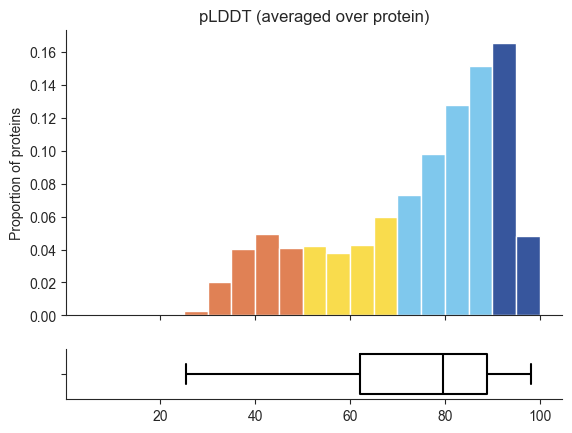

In [30]:
# plotting the pLDDT
sns.set_style("ticks", {"axes.grid" : False})
f, (ax_hist, ax_box) = plt.subplots(2, sharex = True, gridspec_kw = {"height_ratios": (.85, .15)})
plddtF = sns.histplot(x = data_plddt["avg_pLDDT"], bins = [5, 10, 15, 20, 25, 30, 35, 40, 45, 50, 55, 60, 65, 70, 75, 80, 85, 90, 95, 100], 
                      stat = "proportion", ax = ax_hist)
sns.despine()
plddtF.set(title = "pLDDT (averaged over protein)", xlabel = "pLDDT", ylabel = "Proportion of proteins")
# put in AlphaFold pLDDT color scheme
for i in range(0,9):
    plddtF.patches[i].set_facecolor([0.8784, 0.5059, 0.3333])
for i in range(9,13):
    plddtF.patches[i].set_facecolor([0.9765, 0.8627, 0.3020])
for i in range(13,17):
    plddtF.patches[i].set_facecolor([0.4980, 0.7843, 0.9294])
for i in range(17,19):
    plddtF.patches[i].set_facecolor([0.2157, 0.3373, 0.6157])
sns.boxplot(data_plddt["avg_pLDDT"], ax = ax_box, orient = "h", fill = False, color = "black")
ax_box.set(xlabel = "")

Overall, the majority of our structures were accurately predicted, which enables further downstream analysis. 

#### Goal 4 : prepare necessary files for analysing protein structures of these proteins on HPC

Now that we have these protein structures, we can assess whether they are structurally similar to other proteins annotated as 'acetyltransferases'. We will do this by using FoldSeek to compare our proteins against the PDB and AlphaFold database. This will be achieved in batches of 300 proteins at a time. In order to do so, we again have to prepare jobs for the HPC. This entails copying and organizing the relevant structure files, and making the job scripts and job arrays.

In [ ]:
os.mkdir(os.path.join(pipeline_search_dir, "c_assess_unknown", "structure_comparison"))

In [ ]:
# copying the structure files
for index_batch, batch in enumerate(list(batched(proteins_structure_predicted, 300))):
    os.mkdir(os.path.join(pipeline_search_dir, "c_assess_unknown", "structure_comparison", f"batch_{index_batch}"))
    for uid in batch: 
        # check if protein structures relaxed
        if uid in relaxation_issue_uids:
            # get file name/path with varable model number
            pdb = f"{uid}_unrelaxed_rank_1_model_[12345]_ptmx1.pdb"
            for file in glob.glob(os.path.join(pipeline_search_dir, "c_assess_unknown", "structure_prediction", "results", uid, pdb)):
                shutil.copyfile(file,
                                os.path.join(pipeline_search_dir, "c_assess_unknown", "structure_comparison", 
                                             f"batch_{index_batch}", f"{uid}_best.pdb"))
    # for proteins with relaxed structure, we copy the relaxed structure    
        else:
            relaxed_path = os.path.join(pipeline_search_dir, "c_assess_unknown", "structure_prediction", "results", uid, f"{uid}_relaxed.pdb")
            shutil.copyfile(relaxed_path, 
                            os.path.join(pipeline_search_dir, "c_assess_unknown", "structure_comparison", 
                                         f"batch_{index_batch}", f"{uid}_relaxed.pdb"))

In [ ]:
# creating job scripts and job array data files
for index_batch, batch in enumerate(list(batched(proteins_structure_predicted, 300))):
    batch_dir = os.path.join(pipeline_search_dir, "c_assess_unknown", "structure_comparison", f"batch_{index_batch}")
    files = os.listdir(batch_dir)
    # create data file per batch
        # copy template
    shutil.copyfile(os.path.join(master_dir, "templates", "data_foldseek_5.csv"), os.path.join(batch_dir, "data_foldseek_5.csv"))
        # modify template
    with open(os.path.join(batch_dir, "data_foldseek_5.csv"), "a+") as data_file:
        for batch in list(batched(files, 5)):
            string = ""
            for protein_pdb in batch:
                if "relaxed.pdb" in protein_pdb:
                    ncbi_uid = protein_pdb.removesuffix("_relaxed.pdb")
                elif "best.pdb" in protein_pdb:
                    ncbi_uid = protein_pdb.removesuffix("_best.pdb")
                aln_pdb = f"{ncbi_uid}_aln_pdb.tsv"
                aln_af50m = f"{ncbi_uid}_aln_af50m.tsv"
                string += f"{protein_pdb},{aln_pdb},{aln_af50m},"
            string = string.removesuffix(",")
            string += "\n"
            data_file.write(string)
    #  copy job script into batch
    shutil.copyfile(os.path.join(master_dir, "templates", "script_foldseek_5.slurm"), os.path.join(batch_dir, "script_foldseek_5.slurm")) 

We can transfer this to the HPC and submit our job, using atools.

*Note: The job script and slurm output file have been post edited to remove personal information (e-mail, HPC credit, etc.).*

#### Goal 5: identify proteins with likely acetyltransferase function based on predicted protein structure & similar protein structures

Using the created scripts, protein structures were compared to the PDB and AlphaFold database on the HPC. To keep it all organized, the batch folder structure is lifted, the input files are moved to the folder `foldseek_in`, and the output files are moved to the folder `foldseek_out`.

In [ ]:
# create general directories
os.mkdir(os.path.join(pipeline_search_dir, "c_assess_unknown", "structure_comparison", "foldseek_in"))
os.mkdir(os.path.join(pipeline_search_dir, "c_assess_unknown", "structure_comparison", "foldseek_out"))

In [ ]:
# moving all data 
for batch_num in range(0, 35):
    batch_path = os.path.join(pipeline_search_dir, "c_assess_unknown", "structure_comparison", f"batch_{batch_num}")
    for file in os.listdir(batch_path):
        if ".pdb" in file:
            dst = os.path.join(pipeline_search_dir, "c_assess_unknown", "structure_comparison", "foldseek_in", file)
        elif ".csv" in file:
            newfile = file.replace(".csv", f"_batch_{batch_num}.csv")
            dst = os.path.join(pipeline_search_dir, "c_assess_unknown", "structure_comparison", "foldseek_in", newfile)
        elif ".slurm" in file:
            newfile = file.replace(".slurm", f"_batch_{batch_num}.slurm")
            dst = os.path.join(pipeline_search_dir, "c_assess_unknown", "structure_comparison", "foldseek_in", newfile)
        else:
            dst = os.path.join(pipeline_search_dir, "c_assess_unknown", "structure_comparison", "foldseek_out", file)
        shutil.move(os.path.join(batch_path, file), dst)

While the comparison of our structures has been done, the output files are not very interpretable: matched proteins are described based on UniProt ID or PDB ID. Hence, we have to process the output to link protein names to these identifiers. 

In addition, we will also apply some quality filters to our hits. Briefly, we will filter based on:
- probability of our protein and its match to belong to the same SCOP class: > 50%
- quality of the alignment: alignment lDDT > 50% 
- likelihood of the hit: E-value cutoff E-3 (FoldSeek default)
- quality of the aligned region of input protein: average plDDT of aligned region > 70 (standard AlphaFold cut-off)

In order to do so, we write functions to extract these features, and to match the PDB/UniProt information to protein names. We fetch the latest names using the API, to get the most up-to-date information (instead of relying on the annotations stored in the database header files).

In [ ]:
os.mkdir(os.path.join(pipeline_search_dir, "c_assess_unknown", "structure_comparison",  "output_processed"))

##### Step 0 - Filtering the FoldSeek results

As a first step, we will filter all our FoldSeek results based on the filters explained above.

In [31]:
 # define a PDB parser
p = PDBParser()

In [32]:
 # function for calculating average pLDDT of aligned region on FoldSeek results
def get_pLDDT(structure, start, stop):
    for model in structure:
        for chain in model:
            count_residue = 0
            pLDDT_chain = 0
            for residue in chain:
                if residue.id[1] in range(start, stop + 1):
                    count_residue += 1
                    count_atom = 0
                    pLDDT_atom = 0
                    for atom in residue:
                        count_atom += 1
                        pLDDT_atom += atom.get_bfactor()
                    pLDDT_res = round(pLDDT_atom/count_atom, 2)
                    pLDDT_chain += pLDDT_res
            pLDDT_range = round(pLDDT_chain/count_residue, 2)
    return pLDDT_range

*This was executed in July 2024, and not repeated here. A rerun should reproduce the original files, but it takes approximately 3 hours to rerun. As a result, we will simply use the generated files downstream.*

In [ ]:
# looping over proteins
for uid in proteins_structure_predicted:
    # dealing with relaxation issue
    if uid in relaxation_issue_uids:
        # get file name/path with varable model number
        pdb = f"{uid}_unrelaxed_rank_1_model_[12345]_ptmx1.pdb"
        for file in glob.glob(os.path.join(pipeline_search_dir, "c_assess_unknown", "structure_prediction", "results", uid, pdb)):
            structure = p.get_structure(uid, file)
    else:
        structure = p.get_structure(uid, os.path.join(pipeline_search_dir, "c_assess_unknown", "structure_prediction", "results", 
                                                      uid, f"{uid}_relaxed.pdb"))
    # filtering hits against AF50m database
        # reading in the data
    data_af50m = pd.read_table(os.path.join(pipeline_search_dir, "c_assess_unknown", "structure_comparison", "foldseek_out", f"{uid}_aln_af50m.tsv"), 
                               header = None, names = ["query", "target", "fident", "alnlen", "mismatch", "gapopen", "qstart", "qend",
                                                       "tstart", "tend", "evalue", "bits", "prob", "lddt", "lddtfull"])
        # adding AlphaFold quality metrics - pLDDT of aligned region query
    for i in range(0, len(data_af50m)):
        data_af50m.at[i, "pLDDT_qAln"] = get_pLDDT(structure, data_af50m.at[i, "qstart"], data_af50m.at[i, "qend"])
        # filtering based on FoldSeek parameters & AF model accuracy
    data_af50m_filtered = data_af50m
    if len(data_af50m_filtered) != 0:
        data_af50m_filtered = data_af50m_filtered[(data_af50m_filtered["prob"] > 0.5) & (data_af50m_filtered["evalue"] < 1e-3) 
            & (data_af50m_filtered["lddt"] >= 0.5) & (data_af50m_filtered["pLDDT_qAln"] >= 0.7)]
    data_af50m_filtered = data_af50m_filtered.reset_index()
        # store filtered FoldSeek results
    data_af50m_filtered.to_csv(os.path.join(pipeline_search_dir, "c_assess_unknown", "structure_comparison",  "output_processed", 
                                            f"{uid}_foldseek_af50m_filtered.tsv"), sep = "\t", index = False)    
    # filtering hits against PDB database
        # reading in the data
    data_pdb = pd.read_table(os.path.join(pipeline_search_dir, "c_assess_unknown", "structure_comparison", "foldseek_out", f"{uid}_aln_pdb.tsv"), 
                             header = None, names = ["query", "target", "fident", "alnlen", "mismatch", "gapopen",
                                                     "qstart", "qend", "tstart", "tend", "evalue", "bits", "prob", "lddt", "lddtfull"])
        # adding AlphaFold quality metrics - pLDDT of aligned region query
    for i in range(0, len(data_pdb)):
        data_pdb.at[i, "pLDDT_qAln"] = get_pLDDT(structure, data_pdb.at[i, "qstart"], data_pdb.at[i, "qend"])
        # filtering based on FoldSeek parameters & AF model accuracy
    data_pdb_filtered = data_pdb
    if len(data_pdb_filtered) != 0:
        data_pdb_filtered = data_pdb_filtered[(data_pdb_filtered["prob"] > 0.5) & (data_pdb_filtered["evalue"] < 1e-3) 
            & (data_pdb_filtered["lddt"] >= 0.5) & (data_pdb_filtered["pLDDT_qAln"] >= 0.7)]
    data_pdb_filtered = data_pdb_filtered.reset_index()
        # store filtered FoldSeek results
    data_pdb_filtered.to_csv(os.path.join(pipeline_search_dir, "c_assess_unknown", "structure_comparison",  "output_processed", 
                                          f"{uid}_foldseek_pdb_filtered.tsv"), sep = "\t", index = False)

##### Step 1 - Extracting the UniProt identifiers from the filtered FoldSeek output files

Then, we have to accumulate all the UniProt identifiers we wish to query for up-to-date protein names. For the AlphaFold database results, this information can simply be fetched from the FoldSeek output.

In [33]:
# function to extract UniProt ID from the FoldSeek target column
def get_UniProtID_from_target(target):
    uniprot_id = target.split('-')[1]
    return uniprot_id

In [34]:
# instantiate empty dictionary
dict_af50m_UniProtID_NCBIuid = {} 

In [35]:
# looping over proteins
for uid in proteins_structure_predicted:
    # read the filtered data
    filtered_foldseek = pd.read_csv(os.path.join(pipeline_search_dir, "c_assess_unknown", "structure_comparison",  "output_processed", 
                                                 f"{uid}_foldseek_af50m_filtered.tsv"), sep = "\t")
    # check if it has any content
    if not filtered_foldseek.empty:
        # loop over entries
        for i in range(0, len(filtered_foldseek)):
            # extract UniProt ID
            uniprot_id = get_UniProtID_from_target(filtered_foldseek.at[i, "target"])
            # if UniProt ID already in dictionary: add NCBI uids to list of already matched NCBI uids as value for the UniProt ID
            if uniprot_id in dict_af50m_UniProtID_NCBIuid.keys():
                prot_list = dict_af50m_UniProtID_NCBIuid.get(uniprot_id)
            # if UniProt ID not yet in dictionary: create new key-value pair linking NCBI uids to UniProt ID
            if uniprot_id not in dict_af50m_UniProtID_NCBIuid.keys():
                prot_list = list()
            prot_list.append(uid)
            dict_af50m_UniProtID_NCBIuid[uniprot_id] = list(set(prot_list))

For the PDB, we first have to cross link PDB identifier and chain combinations to UniProt identifiers. 

We will exclude any obsolete PDB identifiers. *This was executed in July, 2024, and not repeated here, as which entries are obsolete might have changed.*

In [ ]:
# list of obsolete PDB IDs on date of search (July 15th, 2024)
obsolete_ids = Bio.PDB.PDBList.get_all_obsolete(Bio.PDB.PDBList())

To be able to reproduce the original list of obsolete PDB identifiers, we can just read in the data from that time:

In [36]:
# read from file
with open(os.path.join(master_dir, "associated_data", "list_obsolete_PDB_ids_15jul2024.txt"), "r") as file:
    obsolete_ids = [line.strip() for line in file]

In [37]:
# necessary functions to ...

# from FoldSeek target column, extract PDB id and chain
def get_PDBid_chain_from_target(target):
    pdb_id = target.split('.')[0]
    chain = target.split('_')[-1]
    return pdb_id, chain

# check if PDB ID is obsolete
def check_PDBid_active(pdb_id, obsolete_list):
    if pdb_id.upper() in obsolete_list:
        return False
    else:
        return True

# from PDB ID, get all PDB polymer entities
def get_PDB_entities_from_entry(pdb_id):
    url = f"https://data.rcsb.org/rest/v1/core/entry/{pdb_id}"
    r = sess.get(url)
    data = json.loads(r.text)
    return data["rcsb_entry_container_identifiers"].get("polymer_entity_ids")

# match PDB entity to protein chain
def get_PDB_entity_with_chain(entity_ids, pdb_id, chain):
    for entity in entity_ids:
        url = f"https://data.rcsb.org/rest/v1/core/polymer_entity/{pdb_id}/{entity}"
        r = sess.get(url)
        data = json.loads(r.text)
        # assumption: FoldSeek gives author chain naming, not PDB renamed chain names
        if chain in data["rcsb_polymer_entity_container_identifiers"].get("auth_asym_ids"):
            return entity
        else:
            continue

# get UniProt ID based on the PDB ID and entity (corresponding to the chain reported by FoldSeek)
def get_UniProt_from_PDB_entity(pdb_id, entity):
    url = f"https://data.rcsb.org/rest/v1/core/polymer_entity/{pdb_id}/{entity}"
    r = sess.get(url)
    if not r.ok:
      r.raise_for_status()
    data = json.loads(r.text)
    return data["rcsb_polymer_entity_container_identifiers"].get("uniprot_ids")

In [38]:
# instantiate empty dictionaries
dict_pdb_UniProtID_NCBIuid = {}
dict_pdb_PDBidch_UniProtID = {}

*The following code was executed in July, 2024, and not repeated here, as UniProt and/or PDB might have been updated since then.*

In [ ]:
# looping over proteins
for uid in proteins_structure_predicted:
    # read the filtered data
    filtered_foldseek = pd.read_csv(os.path.join(pipeline_search_dir, "c_assess_unknown", "structure_comparison",  "output_processed", 
                                                 f"{uid}_foldseek_pdb_filtered.tsv"), sep = "\t")
    # check if it has any content
    if not filtered_foldseek.empty:
        # loop over entries
        for i in range(0, len(filtered_foldseek)):
            # extract PDB ID and chain
            pdb_id, chain = get_PDBid_chain_from_target(filtered_foldseek.at[i, "target"])
            # if PDB ID chain combo already in dictionary
            if f"{pdb_id}_{chain}" in dict_pdb_PDBidch_UniProtID.keys():
                # get UniProt ID previously stored
                uniprot_ids = dict_pdb_PDBidch_UniProtID.get(f"{pdb_id}_{chain}")
                if uniprot_ids is not None:
                    for uniprot_id in uniprot_ids:
                        # add NCBI uid to list of matched UniProt IDs
                        if uniprot_id not in dict_pdb_UniProtID_NCBIuid.keys():
                            prot_list = list()
                        if uniprot_id in dict_pdb_UniProtID_NCBIuid.keys():
                            prot_list = dict_pdb_UniProtID_NCBIuid.get(uniprot_id)
                        prot_list.append(uid)
                        dict_pdb_UniProtID_NCBIuid[uniprot_id] = list(set(prot_list))
                    
            # if PDB ID chain combo not yet in dictionary
            if f"{pdb_id}_{chain}" not in dict_pdb_PDBidch_UniProtID.keys():
                # check if PDB ID is obsolete
                if not check_PDBid_active(pdb_id, obsolete_ids):
                    # if obsolete, instead of storing a UniProt ID we store "Obsolete PDB ID"
                    dict_pdb_PDBidch_UniProtID[f"{pdb_id}_{chain}"] = "Obsolete PDB ID"
                if check_PDBid_active(pdb_id, obsolete_ids):
                    # fetch UniProt ID(s) - this can be multiple
                    uniprot_ids = get_UniProt_from_PDB_entity(pdb_id, get_PDB_entity_with_chain(get_PDB_entities_from_entry(pdb_id), pdb_id, chain))
                    # add link PDB id chain combo to UniProt IDs
                    dict_pdb_PDBidch_UniProtID[f"{pdb_id}_{chain}"] = uniprot_ids
                    if uniprot_ids is not None:
                    # link UniProt IDs to NCBI protein ids
                        for uniprot_id in uniprot_ids:
                            if uniprot_id not in dict_pdb_UniProtID_NCBIuid.keys():
                                prot_list = list()
                            if uniprot_id in dict_pdb_UniProtID_NCBIuid.keys():
                                prot_list = dict_pdb_UniProtID_NCBIuid.get(uniprot_id)
                            prot_list.append(uid)
                            dict_pdb_UniProtID_NCBIuid[uniprot_id] = list(set(prot_list))

To be able to reproduce the results from July '24, we can just read in the data from that time:

In [39]:
# reading in the map between PDB ID + chain and UniProt ID
    # reading from file
with open(os.path.join(master_dir, "associated_data", "dict_pdb_PDBidch_UniProtID_jul2024.csv"), newline = "") as csvfile:
    reader = csv.DictReader(csvfile)
    for row in reader:
        dict_pdb_PDBidch_UniProtID = row
    # proper parsing of lists in the values
for key, value in dict_pdb_PDBidch_UniProtID.items():
    updated_value = list()
    if "Obsolete PDB ID" in value:
        updated_value = "Obsolete PDB ID"
    elif value == "":
        updated_value = None
    elif "," not in value:
        updated_value.append(value[2:-2])
    elif "," in value:
        cleaned_value = value[1:-1]
        for entry in cleaned_value.split(","):
            updated_value.append(entry.strip()[1:-1])
    dict_pdb_PDBidch_UniProtID[key] = updated_value

In [40]:
# reading in the map between UniProt and NCBI uid, for the PDB results
    # reading from file
with open(os.path.join(master_dir, "associated_data", "dict_pdb_UniProtID_NCBIuid_jul2024.csv"), newline = "") as csvfile:
    reader = csv.DictReader(csvfile)
    for row in reader:
        dict_pdb_UniProtID_NCBIuid = row
    # proper parsing of lists in the values
for key, value in dict_pdb_UniProtID_NCBIuid.items():
    updated_value = list()
    if "," not in value:
        updated_value.append(value[2:-2])
    elif "," in value:
        cleaned_value = value[1:-1]
        for entry in cleaned_value.split(","):
            updated_value.append(entry.strip()[1:-1])
    dict_pdb_UniProtID_NCBIuid[key] = updated_value

##### Step 2 - Obtaining the UniProt function description based on the UniProt identifiers

Next, we will extract the function description for all proteins for which we obtained the UniProt identifiers from the filtered FoldSeek results. 

In [41]:
# functions to ...

# get protein name, for a single UniProt ID
def get_protein_name_string(uniprot_id):
    # note: unsure if protein_name is a required field, if we get errors, look into this!
    url = f"https://rest.uniprot.org/uniprotkb/search?query={uniprot_id}&fields=protein_name&format=tsv"
    r = sess.get(url)
    r.raise_for_status()
    content = r.text
    names = content.split('\n')[1:-1]
    # if the UniProt entry was marked as obsolete, access its UniParc accession
    if "deleted" in names:
        try:
            return ";".join([str(name) for name in get_uniparc_entry(uniprot_id)])
        except TypeError:
            return "WARNING UniProt ID is obsolete and issue with fetching UniParc information"
    else:
        return ";".join([str(name) for name in names])

# get protein names (and whether the protein is still in UniProt) from a UniParc entry matching the obsolete UniProt ID
def get_uniparc_entry(uniprot_id):
    requestURL = f"https://www.ebi.ac.uk/proteins/api/uniparc/accession/{uniprot_id}"
    r = requests.get(requestURL, headers={ "Accept" : "application/json"})
    if not r.ok:
      r.raise_for_status()
    responseBody = r.text
    data = json.loads(r.text)
    uniparc_entries = []
    uniparc_entries.append("WARNING UniProt ID obsolete, info fetched from UniParc")
    for i in range(0, len(data["dbReference"])):
        for j in data["dbReference"][i].get("property"):
            if j.get("type") == "protein_name":
                uniparc_entries.append(f"{data['dbReference'][i].get('id')} : {j.get('value')} (active UniProt ID: {data['dbReference'][i].get('active')})")
    return uniparc_entries

In [42]:
 # list of failed IDs
failed_UniProtID_function = list()
# dict storing functions
dict_UniProtID_function = {}
# get all the UniProt IDs from the two dictionaries:
uniprot_to_search = list(set(list(dict_af50m_UniProtID_NCBIuid.keys()) + list(dict_pdb_UniProtID_NCBIuid.keys())))

*This was executed July 15-16, 2024, on UniProt release 2024_03 and not repeated here as the results might not be reproducible (UniProt can have updated protein annotations, removed proteins, etc.).*

In [ ]:
# search each element, store in dict
for uniprot_id in uniprot_to_search:
    # this loop allows us to rerun upon errors
    if uniprot_id in dict_UniProtID_function.keys():
        continue
    if uniprot_id not in dict_UniProtID_function.keys():
        try:
            function = get_protein_name_string(uniprot_id)
            dict_UniProtID_function[uniprot_id] = function
        except requests.exceptions.ReadTimeout:
            failed_UniProtID_function.append(uniprot_id)
            print(f"Failed to fetch information on UniProt ID {uniprot_id} due to ReadTimeout error. Stored this ID to the list of failed IDs. Try again later.")
        except JSONDecodeError:
            failed_UniProtID_function.append(uniprot_id)
            print(f"Failed to fetch information on UniProt ID {uniprot_id} due to JSON decode error. Stored this ID to the list of failed IDs. Try again later.")
        except requests.exceptions.ConnectionError:
            failed_UniProtID_function.append(uniprot_id)
            print(f"Failed to fetch information on UniProt ID {uniprot_id} due to Connection error. Stored this ID to the list of failed IDs. Try again later.")

To reproduce the results obtained in July '24, we can just read in the data from that time:

In [43]:
# reading in the map between UniProt ID and UniProt protein names
    # since I did not use DictWriter properly, we have created too large fields for DictReader to reader, which I first have to accomodate here
max_int = sys.maxsize
while True:
    # decrease the max_int value by factor 10 
    # as long as the OverflowError occurs.
    try:
        csv.field_size_limit(max_int)
        break
    except OverflowError:
        max_int = int(max_int/10)
csv.field_size_limit(max_int)
    # actually reading in the data
with open(os.path.join(master_dir, "associated_data", "dict_UniProtID_function_jul2024.csv"), newline = "") as csvfile:
    reader = csv.DictReader(csvfile)
    for row in reader:
        dict_UniProtID_function = row

#####  Step 3 - Writing output files with function annotations

Next, we will supplement the filtered FoldSeek output files with the function annotations we just fetched. To save memory, we will only write annotated FoldSeek output files if there is any hit that matches an 'acetyltransferase' or 'GNAT' function description.

In [44]:
 # instantiate lists
    # one with all the UniProt IDs for which the function description contains 'acetyltransferase' or 'GNAT'
uniprot_ids_to_annotate = list()
    # one with all the NCBI uid linked to these UniProt IDs 
    # (i.e., proteins for which at least one of the filtered FoldSeek hits was annotated as 'acetyltransferase' or 'GNAT')
ncbi_uids_to_annotate = list() 

In [45]:
# loop over function dict
for key, value in dict_UniProtID_function.items():
    # get UniProt IDs related to function of interest
    if "acetyltransferase" in value:
        uniprot_ids_to_annotate.append(key)
    if "GNAT" in value:
        uniprot_ids_to_annotate.append(key)

# loop over list of UniProt IDs with function of interest
for uniprot_id in list(set(uniprot_ids_to_annotate)):
    # get NCBI unique identifiers for proteins for which we want to annotate the FoldSeek results fully
    ncbi_uids_to_annotate.append(dict_pdb_UniProtID_NCBIuid.get(uniprot_id))
    ncbi_uids_to_annotate.append(dict_af50m_UniProtID_NCBIuid.get(uniprot_id))

ncbi_uids_to_annotate = [i for i in list(set(collapse(ncbi_uids_to_annotate))) if i is not None]

In [46]:
# looping over proteins
for uid in proteins_structure_predicted:
    if uid in ncbi_uids_to_annotate:
        # af50m hits
        data_af50m_filtered = pd.read_csv(os.path.join(pipeline_search_dir, "c_assess_unknown", "structure_comparison", "output_processed", 
                                                 f"{uid}_foldseek_af50m_filtered.tsv"), sep = "\t")
        if len(data_af50m_filtered) != 0:
            for i in range(0, len(data_af50m_filtered)):
                data_af50m_filtered.at[i, "protein_descr"] = dict_UniProtID_function.get(get_UniProtID_from_target(data_af50m_filtered.at[i, "target"]))
            # store results
        data_af50m_filtered.to_csv(os.path.join(pipeline_search_dir, "c_assess_unknown", "structure_comparison", "output_processed", 
                                                f"{uid}_foldseek_af50m_processed.tsv"), sep = "\t", index = False)     
        # PDB hits
        data_pdb_filtered = pd.read_csv(os.path.join(pipeline_search_dir, "c_assess_unknown", "structure_comparison", "output_processed", 
                                                 f"{uid}_foldseek_pdb_filtered.tsv"), sep = "\t")
        if len(data_pdb_filtered) != 0:
            for i in range(0, len(data_pdb_filtered)):
                pdb_id, chain = get_PDBid_chain_from_target(data_pdb_filtered.at[i, "target"])
                # get uniprot id or obsolete from dictionary
                uniprot_ids = dict_pdb_PDBidch_UniProtID.get(f"{pdb_id}_{chain}")
                if uniprot_ids == "Obsolete PDB ID":
                    data_pdb_filtered.at[i, "protein_descr"] = "WARNING This PDB ID is obsolete, hence, no information could be fetched"
                elif uniprot_ids is None:
                    data_pdb_filtered.at[i, "protein_descr"] = "WARNING No UniProt ID was linked to this PDB entry, hence, no information could be fetched"
                else:
                    string = ""
                    for uniprot_id in uniprot_ids:
                        string += dict_UniProtID_function.get(uniprot_id) + f" [UniProt ID: {uniprot_id}]"
                    data_pdb_filtered.at[i, "protein_descr"] = string
            # store results
        data_pdb_filtered.to_csv(os.path.join(pipeline_search_dir, "c_assess_unknown", "structure_comparison", "output_processed", 
                                                f"{uid}_foldseek_pdb_processed.tsv"), sep = "\t", index = False)   

#### Goal 6: assess likelihood acetyltransferase function based on predicted protein structure & similar protein structures

Now, we have an overview of all protein clusters of unknown function with structural similarity to at least one protein annotated as 'acetyltransferase' and/or 'GNAT' in the PDB and/or AlphaFold database. However, to make sure an acetyltransferase function is the most likely protein function, we will look at all the FoldSeek hits of those proteins, and see if 'acetyltransferase' and or 'GNAT' hits make up at least 50% of all hits. 

Given that we wrote files as soon as either the AlphaFold or the PDB hits contained a protein annotated as 'acetyltransferase' and/or 'GNAT', not every PDB, nor every AlphaFold database FoldSeek result file necessarily has 'acetyltransferase' hits. Let's have a look at which ones do:

In [47]:
# search for 'acetyltransferase' and/or 'GNAT' annotation in PDB FoldSeek hits
protein_act_pdb = list()
# looping over proteins
for uid in ncbi_uids_to_annotate:
    data_pdb_filtered = pd.read_csv(os.path.join(pipeline_search_dir, "c_assess_unknown", "structure_comparison", "output_processed",
                                    f"{uid}_foldseek_pdb_processed.tsv"), sep = "\t")
    if len(data_pdb_filtered) != 0:
        # get annotations
        functions = data_pdb_filtered["protein_descr"].values
        # add protein to list if 'acetyltransferase' and/or 'GNAT' found in annotations
        for function in functions:
            if "acetyltransferase" in function:
                protein_act_pdb.append(uid)
            if "GNAT" in function:
                protein_act_pdb.append(uid)
# create unique overview
unique_protein_act_pdb = list(set(protein_act_pdb))
print(f"{len(unique_protein_act_pdb)} clusters have FoldSeek hits against the PDB annotated as 'acetyltransferases' and/or 'GNAT'.")

33 clusters have FoldSeek hits against the PDB annotated as 'acetyltransferases' and/or 'GNAT'.


In [48]:
# search for annotation in PDB
protein_act_af50m = list()
# looping over proteins
for uid in ncbi_uids_to_annotate:
    data_af50m_filtered = pd.read_csv(os.path.join(pipeline_search_dir, "c_assess_unknown", "structure_comparison", "output_processed",
                                    f"{uid}_foldseek_af50m_processed.tsv"), sep = "\t")
    if len(data_af50m_filtered) != 0:
        # get annotations
        functions = data_af50m_filtered["protein_descr"].values
        # add protein to list if 'acetyltransferase' and/or 'GNAT' found in annotations
        for function in functions:
            if "acetyltransferase" in function:
                protein_act_af50m.append(uid)
            if "GNAT" in function:
                protein_act_af50m.append(uid)
# create unique overview
unique_protein_act_af50m = list(set(protein_act_af50m))
print(f"{len(unique_protein_act_af50m)} clusters have FoldSeek hits against the AlphaFold database annotated as 'acetyltransferases' and/or 'GNAT'.")

314 clusters have FoldSeek hits against the AlphaFold database annotated as 'acetyltransferases' and/or 'GNAT'.


In [49]:
# calculate overlap
protein_act_both = set(unique_protein_act_pdb) & set(unique_protein_act_af50m)
print(f"{len(protein_act_both)} clusters have FoldSeek hits against both the PDB and the AlphaFold database annotated as 'acetyltransferases' and/or 'GNAT'.")

28 clusters have FoldSeek hits against both the PDB and the AlphaFold database annotated as 'acetyltransferases' and/or 'GNAT'.


Now let's have a look at how many of those actually have over 50% 'acetyltransferase' and/or 'GNAT' hits:

In [50]:
# let's look at 'acetyltransferase' annotation consistency for PDB results first
    # empty list to store those with at least 50% 'acetyltransferase' and/or 'GNAT' annotations
protein_50p_act_pdb = list()
    # empty dict to store the percentage of 'acetyltransferase' and/or 'GNAT' annotations
protein_percentage_pdb_dict = {}
# loop over proteins
for uid in unique_protein_act_pdb:
    data_pdb_filtered = pd.read_csv(os.path.join(pipeline_search_dir, "c_assess_unknown", "structure_comparison", "output_processed",
                                    f"{uid}_foldseek_pdb_processed.tsv"), sep = "\t")
    # get annotations
    functions = data_pdb_filtered["protein_descr"].values
    # get total number of annotations
    count_total = len(functions)
    # start with 0 counts for the 'acetyltransferase'/'GNAT' counts
    count_act = count_gnat = count_both = 0
    # start counting
    for function in functions:
        # either acetyltransferase or GNAT
        if ("acetyltransferase" in function.lower()) and ("GNAT" not in function):
            count_act += 1
        if ("GNAT" in function) and ("acetyltransferase" not in function.lower()):
            count_gnat += 1
        # GNAT acetyltransferase
        if ("acetyltransferase" in function.lower()) and ("GNAT" in function):
            count_both += 1 
    # store the percentage of 'acetyltransferase' and/or 'GNAT' annotations
    protein_percentage_pdb_dict[uid] = round(((count_act + count_gnat + count_both)/count_total), 2)
    # add to list if over 50% of annotations is 'acetyltransferase' and/or 'GNAT' annotation
    if count_act + count_gnat + count_both >= count_total/2:
        protein_50p_act_pdb.append(uid)
print(f"{len(protein_50p_act_pdb)} clusters have at least 50% of their FoldSeek hits against the PDB annotated as 'acetyltransferases' and/or 'GNAT'.")

25 clusters have at least 50% of their FoldSeek hits against the PDB annotated as 'acetyltransferases' and/or 'GNAT'.


We will do the same for the AlphaFold database hits. However, as many of the proteins in the AlphaFold database are still unannotated, and we do not want those to bias our results (unannotated proteins could be acetyltransferases after all), we will calculate the fraction of acetyltransferase including and excluding the count of 'unannotated' proteins, to see how much this would impact our results.

In [51]:
# let's look at 'acetyltransferase' annotation consistency for PDB results first
    # empty list to store those with at least 50% 'acetyltransferase' and/or 'GNAT' annotations
protein_50p_act_af50m = list()
    # empty list to store those with at least 50% 'acetyltransferase' and/or 'GNAT' annotations 
        # after correcting the total number for the unannotated hits    
protein_50p_corr_act_af50m = list()
    # empty dict to store the percentage of 'acetyltransferase' and/or 'GNAT' annotations
protein_percentage_af50m_dict = {}
    # empty dict to store the percentage of 'acetyltransferase' and/or 'GNAT' annotations
        # after correcting the total number for the unannotated hits  
protein_percentage_af50m_corr_dict = {}
# loop over proteins
for uid in unique_protein_act_af50m:
    data_af50m_filtered = pd.read_csv(os.path.join(pipeline_search_dir, "c_assess_unknown", "structure_comparison", "output_processed",
                                    f"{uid}_foldseek_af50m_processed.tsv"), sep = "\t")
    # get annotations
    functions = data_af50m_filtered["protein_descr"].values
    # get total number of annotations
    count_total = len(functions)
    # start with 0 counts for the 'acetyltransferase'/'GNAT' counts + count of 'unannotated' proteins
    count_act = count_gnat = count_both = count_unknown = 0
    # start counting
    for function in functions:
        # either acetyltransferase or GNAT
        if ("acetyltransferase" in function.lower()) and ("GNAT" not in function):
            count_act += 1
        if ("GNAT" in function) and ("acetyltransferase" not in function.lower()):
            count_gnat += 1
        # GNAT acetyltransferase
        if ("acetyltransferase" in function.lower()) and ("GNAT" in function):
            count_both += 1 
        # not a GNAT/acetyltransferase, but a protein of unknown function, 
            # as identified through the words 'hypothetical' or 'uncharacterized' in the protein description
        if (("hypothetical" in function.lower()) or ("uncharacterized" in function.lower())) and (("acetyltransferase" not in function.lower()) or ("GNAT" not in function)):
            count_unknown += 1
    # store the percentage of 'acetyltransferase' and/or 'GNAT' annotations
    protein_percentage_af50m_dict[uid] = round(((count_act + count_gnat + count_both)/count_total), 2)
    # add to list if over 50% of annotations is 'acetyltransferase' and/or 'GNAT' annotation
    if count_act + count_gnat + count_both >= count_total/2:
        protein_50p_act_af50m.append(uid)
    # store the percentage of 'acetyltransferase' and/or 'GNAT' annotations (after correction)
        # deal with all hits being unannotated
    if count_total == count_unknown:
        protein_percentage_af50m_corr_dict[uid] = 0
    if count_total != count_unknown:
        protein_percentage_af50m_corr_dict[uid] = round(((count_act + count_gnat + count_both)/(count_total-count_unknown)), 2)
    protein_percentage_af50m_dict[uid] = round(((count_act + count_gnat + count_both)/count_total), 2)    
    # add to list if over 50% of annotations is 'acetyltransferase' and/or 'GNAT' annotation (after correction)
    if count_act + count_gnat + count_both >= (count_total - count_unknown)/2:
        protein_50p_corr_act_af50m.append(uid)
print(f"{len(protein_50p_act_af50m)} clusters have at least 50% of their FoldSeek hits against the AlphaFold database annotated as 'acetyltransferases' and/or 'GNAT'.")
print(f"After removing all hits of unannotated proteins, {len(protein_50p_corr_act_af50m)} clusters have at least 50% of their FoldSeek hits against the AlphaFold database annotated as 'acetyltransferases' and/or 'GNAT'.")

26 clusters have at least 50% of their FoldSeek hits against the AlphaFold database annotated as 'acetyltransferases' and/or 'GNAT'.
After removing all hits of unannotated proteins, 43 clusters have at least 50% of their FoldSeek hits against the AlphaFold database annotated as 'acetyltransferases' and/or 'GNAT'.


Let's have a look at how many proteins are in those clusters:

In [52]:
# checking how many proteins are in these clusters
    # count uncorrected
protein_act_all_50p = set(protein_50p_act_af50m + protein_50p_act_pdb)
number_proteins = len(list(cluster_protein_match[cluster_protein_match["cluster_rep"].isin(protein_act_all_50p)]["cluster_member"]))
print(f"In total, {len(protein_act_all_50p)} clusters have at least 50% of their FoldSeek hits (against the AlphaFold database, the PDB, or both) annotated as 'acetyltransferases' and/or 'GNAT'.")
print(f"These {len(protein_act_all_50p)} clusters contain {number_proteins} proteins.")

In total, 29 clusters have at least 50% of their FoldSeek hits (against the AlphaFold database, the PDB, or both) annotated as 'acetyltransferases' and/or 'GNAT'.
These 29 clusters contain 44 proteins.


In [54]:
    # corrected for hits against unknown proteins
protein_act_all_50p_corr = set(protein_50p_corr_act_af50m + protein_50p_act_pdb)
number_proteins_corr = len(list(cluster_protein_match[cluster_protein_match["cluster_rep"].isin(protein_act_all_50p_corr)]["cluster_member"]))
print(f"After correcting for the many unannotated protein in the AlphaFold database, {len(protein_act_all_50p_corr)} clusters have at least 50% of their FoldSeek hits (against the AlphaFold database, the PDB, or both) annotated as 'acetyltransferases' and/or 'GNAT'.")
print(f"These {len(protein_act_all_50p_corr)} clusters contain {number_proteins_corr} proteins.")

After correcting for the many unannotated protein in the AlphaFold database, 44 clusters have at least 50% of their FoldSeek hits (against the AlphaFold database, the PDB, or both) annotated as 'acetyltransferases' and/or 'GNAT'.
These 44 clusters contain 125 proteins.


It seems that while the number of clusters only differs by 15 when deciding to include/exclude FoldSeek hits of unknown function, the total number of phage proteins is dramatically different (nearly triple). As we will be performing more *in silico* and wet lab characterization anyway, let's be more lenient here and include the 44 clusters.

Let's now store the information of all proteins of unknown function belonging to these 44 clusters, in a similar fashion to how we stored the assessed annotated acetyltransferases.

In [55]:
# list of proteins to include
all_unknown_assessed = list(cluster_protein_match[cluster_protein_match["cluster_rep"].isin(protein_act_all_50p_corr)]["cluster_member"])
# extracting these proteins from the unannotated protein dataframe
unannotated_proteins_assessed = unannotated_proteins[unannotated_proteins["ncbi_protein_uid"].isin([int(uid[9:]) for uid in all_unknown_assessed])]
# add in information on phages
unannotated_proteins_assessed_exp = pd.merge(unannotated_proteins_assessed, phage_data, how = "left", on = "name_taxid")
# reorganize to be like the assessed annotated acetyltransferases
unannotated_proteins_assessed_exp["length"] = unannotated_proteins_assessed_exp["ncbi_protein_length"] 
unannotated_proteins_assessed_reorg = unannotated_proteins_assessed_exp[["sequence", "length", "virus_name", "virus_taxid", "name_taxid", "virus_lineage", 
                                                                        "host_name", "host_lineage", "ncbi_protein_uid", "ncbi_protein_name"]]
# store file
unannotated_proteins_assessed_reorg.to_csv(os.path.join(pipeline_search_dir, "c_assess_unknown", "assessed_unknown.tsv"), sep = "\t", index = False)